# EDA - Online Retail II

Just getting familiar with the data before writing the SQL cleaning steps.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## Load it

In [2]:
df = pd.read_excel("../data/raw/online_retail_II.xlsx", sheet_name=None)
df = pd.concat(df.values(), ignore_index=True)
print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## Missing values

In [3]:
df.isna().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

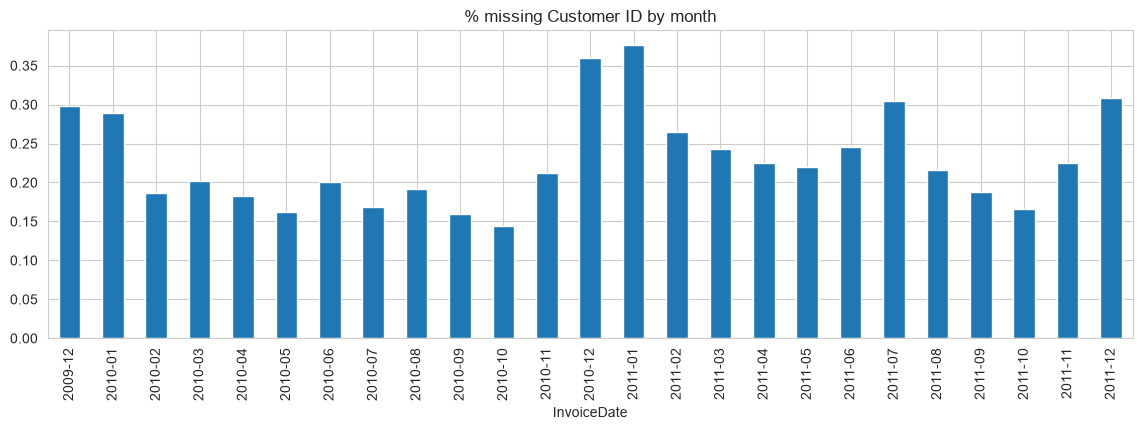

In [4]:
# is missing Customer ID clustered in any month, or just spread out?
df.groupby(df['InvoiceDate'].dt.to_period('M'))['Customer ID'].apply(lambda s: s.isna().mean()) \
  .plot(kind='bar', figsize=(14,4), title='% missing Customer ID by month')
plt.show()

## Duplicates

In [5]:
dupes = df.duplicated(keep=False)
print(f"{dupes.sum():,} duplicate rows ({dupes.mean()*100:.2f}%)")
df[dupes].sort_values(['Invoice','StockCode']).head(10)

67,242 duplicate rows (6.30%)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
379,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01 11:34:00,1.95,16329.0,United Kingdom
365,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
363,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
371,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
362,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01 11:34:00,3.75,16329.0,United Kingdom
368,489517,22130,PARTY CONE CHRISTMAS DECORATION,6,2009-12-01 11:34:00,0.85,16329.0,United Kingdom


## Cancellations (Invoice starts with C)

In [6]:
df['is_cancellation'] = df['Invoice'].astype(str).str.startswith('C')
print(f"{df['is_cancellation'].sum():,} cancellations ({df['is_cancellation'].mean()*100:.2f}%)")
df[df['is_cancellation']]['Quantity'].describe()

19,494 cancellations (1.83%)


count    19494.000000
mean       -25.186827
std        805.104908
min     -80995.000000
25%         -6.000000
50%         -2.000000
75%         -1.000000
max          1.000000
Name: Quantity, dtype: float64

## Weird stock codes

Codes that don't look like normal 5-digit product codes - checking what they actually are.

In [7]:
weird = df.loc[~df['StockCode'].astype(str).str.match(r'^\d{4,6}[A-Za-z]?$'), 'StockCode'].value_counts()
weird.head(20)

StockCode
POST            2122
DOT             1446
M               1421
15056BL          923
C2               282
79323LP          232
D                177
79323GR          123
S                104
BANK CHARGES     102
15056bl           93
ADJUST            67
AMAZONFEE         43
DCGS0058          31
gift_0001_30      29
gift_0001_20      29
DCGSSGIRL         25
DCGSSBOY          23
PADS              19
gift_0001_10      16
Name: count, dtype: int64

In [8]:
for c in ['PADS', 'ADJUST', 'B']:
    print(c, '->', df.loc[df['StockCode']==c, 'Description'].mode().values)

PADS -> ['PADS TO MATCH ALL CUSHIONS']
ADJUST -> ['Adjustment by john on 26/01/2010 16']
B -> ['Adjust bad debt']


PADS turns out to be a real product ('PADS TO MATCH ALL CUSHIONS'), keeping it.
ADJUST and B are staff adjustments, not real products, dropping those.

## Price/quantity sanity check

In [9]:
print('rows with price <= 0:', (df['Price'] <= 0).sum())
df[df['Price'] <= 0].head()

rows with price <= 0: 6207


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,is_cancellation
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,False
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,False


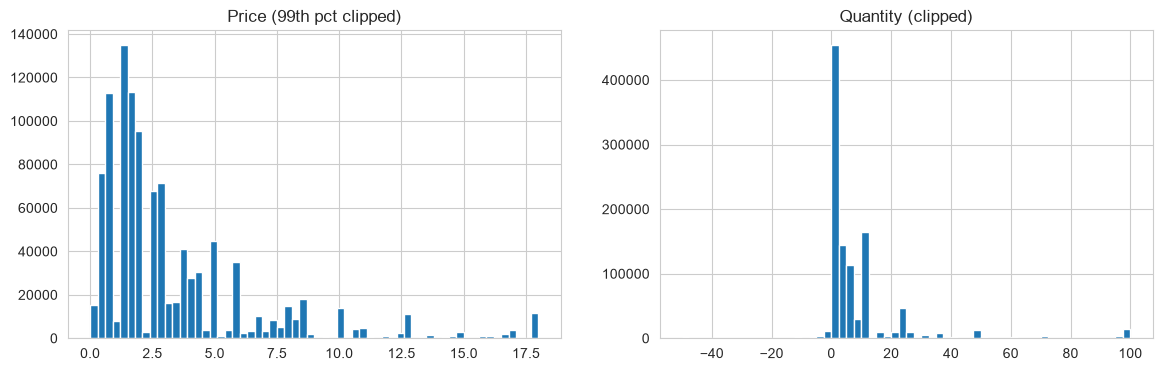

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
df.loc[df['Price']>0, 'Price'].clip(upper=df['Price'].quantile(0.99)).hist(bins=60, ax=ax[0])
ax[0].set_title('Price (99th pct clipped)')
df['Quantity'].clip(-50, 100).hist(bins=60, ax=ax[1])
ax[1].set_title('Quantity (clipped)')
plt.show()

## Bulk-order concentration check

In [11]:
print(df['Quantity'].describe(percentiles=[.9,.99,.999]))
print(df.nlargest(20, 'Quantity')[['StockCode','Quantity','InvoiceDate']])


count    1.067371e+06
mean     9.938898e+00
std      1.727058e+02
min     -8.099500e+04
50%      3.000000e+00
90%      2.400000e+01
99%      1.000000e+02
99.9%    5.000000e+02
max      8.099500e+04
Name: Quantity, dtype: float64
        StockCode  Quantity         InvoiceDate
1065882     23843     80995 2011-12-09 09:15:00
587080      23166     74215 2011-01-18 10:01:00
90857       37410     19152 2010-02-15 11:57:00
127166      21099     12960 2010-03-17 13:09:00
127168      21091     12960 2010-03-17 13:09:00
127169      21085     12744 2010-03-17 13:09:00
1027583     84826     12540 2011-11-25 15:57:00
127167      21092     12480 2010-03-17 13:09:00
192197      84016     10200 2010-05-10 14:55:00
135027      21984     10000 2010-03-23 15:36:00
135028      21982     10000 2010-03-23 15:36:00
135029      21980     10000 2010-03-23 15:36:00
135030      21981     10000 2010-03-23 15:36:00
296420      22759      9600 2010-08-05 15:55:00
93677       85220      9456 2010-02-17 10:51:00
432

## Time range & seasonality

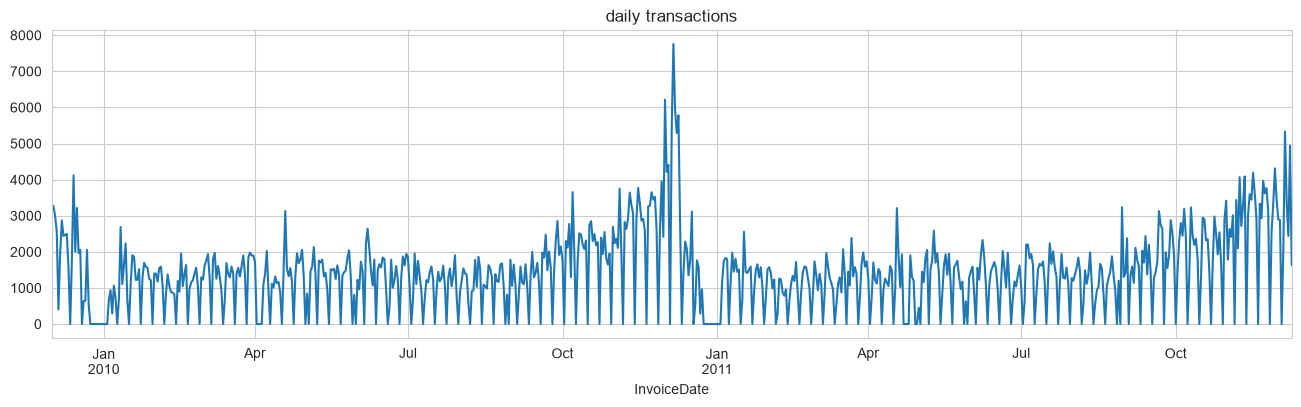

In [12]:
df.set_index('InvoiceDate').resample('D').size().plot(figsize=(16,4), title='daily transactions')
plt.show()

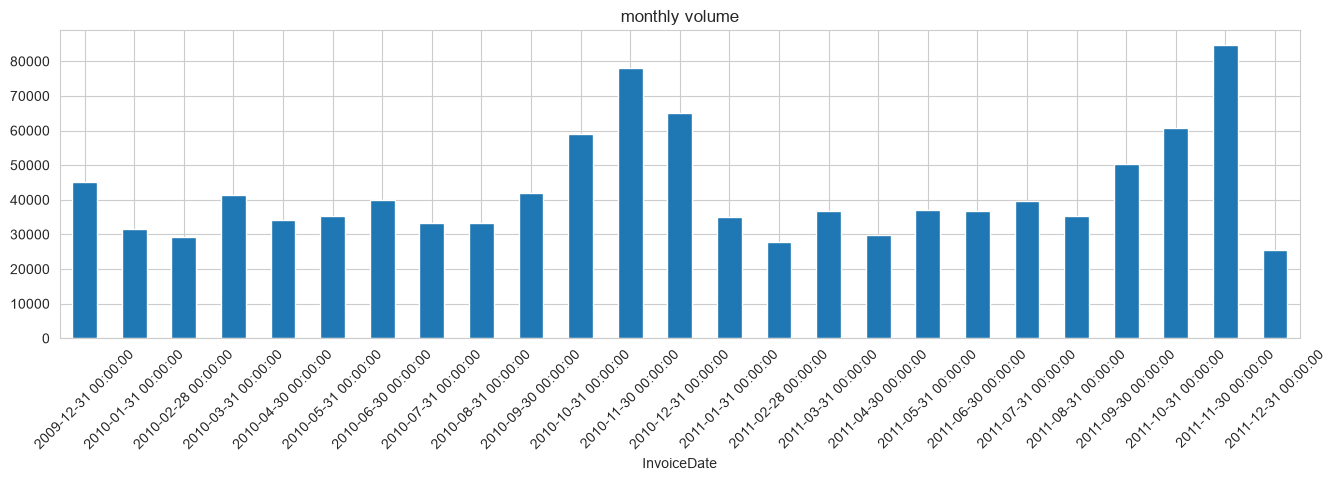

In [13]:
df.set_index('InvoiceDate').resample('ME').size().plot(kind='bar', figsize=(16,4), title='monthly volume')
plt.xticks(rotation=45)
plt.show()

Clear holiday bump every Nov/Dec, good - that's what days_to_christmas should pick up on.

## Countries

In [14]:
df['Country'].value_counts().head(10)

Country
United Kingdom    981330
EIRE               17866
Germany            17624
France             14330
Netherlands         5140
Spain               3811
Switzerland         3189
Belgium             3123
Portugal            2620
Australia           1913
Name: count, dtype: int64

## How intermittent is demand per SKU?

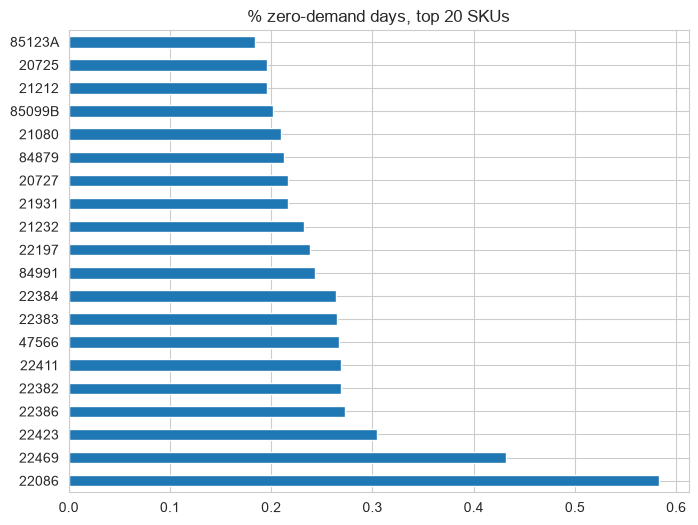

In [15]:
top_skus = df['StockCode'].value_counts().head(20).index
daily_sku = df[~df['is_cancellation']].groupby(['StockCode', df['InvoiceDate'].dt.date])['Quantity'].sum()
all_dates = pd.date_range(df['InvoiceDate'].min().date(), df['InvoiceDate'].max().date())

zero_pct = {}
for sku in top_skus:
    sold_on = set(daily_sku.loc[sku].index) if sku in daily_sku.index.get_level_values(0) else set()
    zero_pct[sku] = 1 - len(sold_on) / len(all_dates)

pd.Series(zero_pct).sort_values(ascending=False).plot(kind='barh', figsize=(8,6), title='% zero-demand days, top 20 SKUs')
plt.show()

Even the best-selling SKUs have a lot of zero-demand days. Demand here is bursty, not smooth -
that's why the models downstream use a Tweedie objective instead of plain regression.

## Category guess

No real category column exists, so using the first 2 chars of stock_code as a rough grouping.

In [16]:
df['cat_guess'] = df['StockCode'].astype(str).str[:2]
df.groupby('cat_guess').agg(n=('StockCode','size'), skus=('StockCode','nunique'), 
                            price_std=('Price','std')).sort_values('n', ascending=False).head(15)

,n,skus,price_std
cat_guess,,,
22,401657,940,5.799920
21,249615,863,3.646342
23,93500,605,3.374508
84,76671,690,7.470013
20,66201,292,2.867421
85,55525,349,3.510437
82,19948,54,2.669701
47,15033,108,3.069961
90,11298,422,2.788093


## Save combined file

This is what gets loaded into raw_online_retail for the SQL pipeline.

In [17]:
cols = ['Invoice','StockCode','Description','Quantity','InvoiceDate','Price','Customer ID','Country']
df[cols].to_csv('../data/raw/online_retail_combined.csv', index=False)
print('saved', df[cols].shape)

saved (1067371, 8)


## Summary

- Customer ID missing on ~23% of rows, no monthly spike so probably guest checkouts, not a bug. Kept for SKU-level demand.
- ~6% exact duplicate rows, looks like a known re-export issue in this dataset. Dropping in SQL.
- ~1.8% cancellations, kept and netted against sales rather than dropped.
- Confirmed and excluded non-product codes: POST, DOT, M, C2, D, S, BANK CHARGES, ADJUST, AMAZONFEE, CRUK, TEST001, B.
- Confirmed and kept: PADS (real product despite odd code).
- ~6.2k rows with price <= 0, mostly samples/damages, dropping those.
- Full 2009-12 to 2011-12 range, clear holiday seasonality.
- UK is ~92% of rows, expected, not restricting to UK only since we model at SKU/date grain.
- Demand is sparse/bursty even for top SKUs -> Tweedie objective, days_since_last_sale feature.
- Category-by-prefix heuristic is decent for big categories, not perfect for small ones (e.g. postage codes).